
# Введение в RAG — Часть 1



# Цели первой части встречи

* Понять идею разделения задач на **retrieval + generation** и почему это снижает галлюцинации и стоимость.
* Разобрать **классическую архитектуру RAG**: индекс → retriever (BM25/FAISS) → prompt-компоновка → LLM.
* Собрать **простое retrieval-решение** (BM25) и посмотреть **минимальный dense-retrieval** (FAISS).
* Освоить базовые практики **чанкования**, **оценки качества** и **минимизации галлюцинаций**.



**Почему LLM “знают много, но не ваше”:**
- **Частные данные**: модели не видят ваши закрытые документы.
- **Свежесть**: знания модели фиксированы временем обучения.
- **Контроль фактов**: без внешних источников растёт риск галлюцинаций, сложно проверять.

**Чем RAG отличается от fine-tuning?**
- **RAG** добавляет к запросу релевантный контекст из вашей базы и заставляет модель опираться на него.
- **Fine-tuning** меняет параметры модели под ваш стиль/задачу, но **не** обновляет факты динамически.
- На практике часто сочетают: *тонкая настройка* ⇢ стиль/формат; *RAG* ⇢ факты/знания.



### RAG vs Fine-tuning — короткое сравнение

| Критерий | RAG | Fine-tuning |
|---|---|---|
| Обновление знаний | Легко: переиндексация корпусов | Тяжело: нужен новый цикл обучения |
| Контроль источников | Есть (цитаты/ссылки) | Нет (внутри параметров) |
| Стоимость поддержки | Низкая/средняя (индекс) | Средняя/высокая (переобучение) |
| Риск галлюцинаций | Ниже (опора на контекст) | Выше при отсутствии RAG |
| Когда особенно уместен | Частые изменения в данных, приватные факты | Строгий стиль/формат, доменная речь |



## Концепция RAG (retrieval + generation)

**Идея декомпозиции:**  
1) **Поиск** релевантного контекста (retriever) → 2) **Контролируемая генерация** ответа (LLM).

```
[User Query]
      │
      ▼
[Retriever: BM25 / FAISS / Hybrid]
      │  → Top-k отрывков + метаданные (источники, даты, разделы)
      ▼
[Промпт-компоновка: инструкции + контекст]
      │
      ▼
[LLM → Ответ c цитированием источников]
```

**Что даёт retrieval:**
- Снижение галлюцинаций (ответ опирается на найденные фрагменты).
- Объяснимость (можно приложить источники).
- Обновляемость (перепостроил индекс — и знания обновились).

**Где применяют:**
- Поддержка/FAQ, базы знаний по продукту.
- Поиск по регламентам/контрактам/политикам.
- Техдокументация, аналитика, обзоры.



### Мини-демо: «почему retrieval помогает?» (игрушечный пример без внешних библиотек)

Запустите код ниже: он построит простейший **TF‑IDF (Term Frequency – Inverse Document Frequency)**-подобный ретривер и вернёт **Top‑k** фрагментов.

Идея:

* **TF (term frequency)** = сколько раз термин встречается в документе. Чем чаще, тем «важнее» для данного документа.

* **IDF (inverse document frequency)** = насколько термин уникален в коллекции. Если слово встречается почти во всех документах (например, «и», «компания»), оно мало помогает для поиска. Если слово редкое («BM25», «отпуск»), оно ценное.


In [ ]:
# Игрушечный sparse-retrieval на чистом Python (без внешних пакетов)
import re, math
from collections import Counter, defaultdict

docs = [
    "Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.",
    "Справка: BM25 — классический sparse-ретривер, хорошо работает на маленьких наборах и точных формулировках.",
    "FAISS — библиотека для быстрых векторных (dense) поисков; полезна для семантического сходства запросов и текстов.",
    "Регламент командировок: билеты и гостиница бронируются через корпоративный портал, суточные согласуются заранее.",
    "Обновление базы знаний: при изменениях документов выполните переиндексацию для актуализации ответов RAG."
]

def tokenize(text):
    return re.findall(r"[\w-]+", text.lower(), flags=re.UNICODE)

tokenized = [tokenize(d) for d in docs]
N = len(docs)

# Подсчёт document frequency (df) для idf
df = Counter()
for terms in tokenized:
    for t in set(terms):
        df[t] += 1

def idf(term):
    # смягчённая формула idf
    return math.log((1 + N) / (1 + df[term])) + 1.0

def score_doc(query_terms, doc_terms):
    tf = Counter(doc_terms)
    # простая сумма TF * IDF по термам запроса
    return sum(tf[t] * idf(t) for t in query_terms)

def retrieve(query, k=3):
    q_terms = tokenize(query)
    scored = [(i, score_doc(q_terms, tokenized[i])) for i in range(N)]
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:k]

# Пример запросов — попробуйте разные формулировки
for q in ["Как оформить отпуск?", "Что такое BM25?", "Как обновить базу знаний?"]:
    top = retrieve(q, k=2)
    print(f"\nЗапрос: {q}")
    for rank, (i, s) in enumerate(top, 1):
        print(f"{rank}) score={s:.3f} — {docs[i]}")



Запрос: Как оформить отпуск?
1) score=2.099 — Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.
2) score=0.000 — Справка: BM25 — классический sparse-ретривер, хорошо работает на маленьких наборах и точных формулировках.

Запрос: Что такое BM25?
1) score=2.099 — Справка: BM25 — классический sparse-ретривер, хорошо работает на маленьких наборах и точных формулировках.
2) score=0.000 — Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.

Запрос: Как обновить базу знаний?
1) score=2.099 — Обновление базы знаний: при изменениях документов выполните переиндексацию для актуализации ответов RAG.
2) score=0.000 — Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.


In [ ]:
#@title Шаблон компоновки промпта (без вызова LLM)
def build_prompt(query, retrieved_texts):
    context_block = "\n\n---\n".join(retrieved_texts)
    return f"""Ты — ассистент, отвечающий строго по приведённому контексту.
Если ответа в контексте нет — скажи об этом и предложи, что уточнить.

Вопрос: {query}

Контекст:
{context_block}

Ответ:"""

# Демонстрация: соберём контекст из Top-2 найденных фрагментов
query = "Как оформить отпуск?"
top = retrieve(query, k=2)
ctx = [docs[i] for i, _ in top]
print(build_prompt(query, ctx))

Ты — ассистент, отвечающий строго по приведённому контексту.
Если ответа в контексте нет — скажи об этом и предложи, что уточнить.

Вопрос: Как оформить отпуск?

Контекст:
Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.

---
Справка: BM25 — классический sparse-ретривер, хорошо работает на маленьких наборах и точных формулировках.

Ответ:


### Как интерпретировать результаты

#### 1. Что означает `score`

* Это **сумма TF×IDF по термам запроса**, которые встретились в документе.
* Чем выше `score`, тем больше «веса» общих слов между запросом и документом.
* Если документ не содержит ни одного слова из запроса → `score=0.0`.

По сути:

* **score≈0** → документ не содержит терминов запроса (нерелевантен).
* **score >0** → есть пересечение, и чем больше score, тем релевантнее.

---

#### 2. Примеры интерпретации

##### 🔹 Запрос: *«Как оформить отпуск?»*

* Лучший документ: *«Политика отпусков компании...»* (score=2.099).
  👉 Логично: в запросе слово «отпуск», оно редкое, IDF высокий, совпадение найдено.
* Остальные (BM25, FAISS) не содержат этих слов → score=0.

➡️ Интерпретация: система правильно извлекла нужный документ.

---

##### 🔹 Запрос: *«Что такое BM25?»*

* Лучший документ: *«Справка: BM25...»* (score=2.099).
  👉 Совпадает редкое слово `bm25`, дающее высокий вес.
* Остальные документы не содержат запроса → score=0.

➡️ Интерпретация: ретривер отрабатывает идеально.

---

##### 🔹 Запрос: *«Как обновить базу знаний?»*

* Лучший документ: *«Обновление базы знаний...»* (score=2.099).
  👉 Совпало редкое словосочетание `база знаний`.
* Остальные — нерелевантны.

➡️ Интерпретация: ретривер снова достал именно то, что нужно.

---

##### 🔹 Запрос: *«Нужно согласовать с руководителем?»*

* Два топ-документа получили **одинаковый высокий score=3.386**:

  * *«Политика отпусков...»* (там «согласования с руководителем»),
  * *«Регламент командировок...»* (там «согласуются заранее с руководителем»).
* Это происходит потому, что оба документа содержат несколько терминов из запроса (`нужно/согласовать/руководителем`), и у этих терминов высокий IDF.

➡️ Интерпретация: ретривер не различает «отпуск» и «командировка» — он видит только совпадение слов. Поэтому оба документа кажутся одинаково релевантными.

---

#### 3. Общая логика интерпретации

* **score — не вероятность и не «правильность»**, а лишь мера совпадения слов, взвешенная IDF.
* Сравнивать можно **только внутри одного запроса**.

  * Если score=2.1 у документа A и 0.0 у B → A явно лучше для этого запроса.
  * Но сравнивать score между разными запросами («2.1 здесь лучше, чем 3.3 там») нельзя — это разные шкалы.
* Если несколько документов получили близкие score → они одинаково релевантны и требуют дополнительной обработки (например, reranker на BERT).

---

#### 4. Выводы

* TF-IDF-подобный ретривер хорошо ловит точные совпадения слов.
* Слабое место: он не понимает **синонимы, морфологию и семантику**.
  👉 Например, «отпуск» и «каникулы» он воспримет как разные слова.
* Для таких случаев добавляют:

  * нормализацию (стемминг, лемматизация - pymorphy2),
  * расширение словаря (синонимы),
  * или dense-ретриверы (FAISS, BERT).




In [ ]:

def build_prompt(query, retrieved_texts):
    context_block = "\n\n---\n".join(retrieved_texts)
    return f"""Ты — ассистент, отвечающий строго по приведённому контексту.
Если ответа в контексте нет — скажи об этом и предложи, что уточнить.

Вопрос: {query}

Контекст:
{context_block}

Ответ:"""

# Демонстрация: соберём контекст из Top-2 найденных фрагментов
query = "Демонтаж старых окон?"
top = retrieve(query, k=2)
ctx = [docs[i] for i, _ in top]
print(build_prompt(query, ctx))


Ты — ассистент, отвечающий строго по приведённому контексту.
Если ответа в контексте нет — скажи об этом и предложи, что уточнить.

Вопрос: Демонтаж старых окон?

Контекст:
Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.

---
Справка: BM25 — классический sparse-ретривер, хорошо работает на маленьких наборах и точных формулировках.

Ответ:



## Вопросы
- Где в ваших процессах критична **обновляемость** знаний?
- Какие документы чаще всего нужны пользователям (FAQ, регламенты, договоры)?
- Нужны ли **ссылки на источники** в ответах и какой формат удобнее?
- Что влечёт за собой **отсутствие retrieval** (риски, стоимость, доверие)?


##  Классическая архитектура RAG

**Пайплайн:** источник данных → парсинг → **чанкование (+overlap)** → индекс
**Retriever:**

* **Sparse:** BM25 (просто, быстро, устойчив к малым данным)
* **Dense:** эмбеддинги + **FAISS** (семантика, мультиязычность, масштаб)
  **Reranker (по необходимости):** cross-encoder для точности Top-k
  **Промпт-компоновка:** системные инструкции, формат ответа, **cite-контекст**
  **LLM:** выбор модели, температура, лимиты токенов, стоимость



### Шаблон компоновки промпта (без вызова LLM)

Ниже — минимальный шаблон: соберите Top‑k фрагментов и подставьте в промпт. Это дисциплинирует модель отвечать «по делу».


In [ ]:

# Игрушечный sparse-retrieval на чистом Python (без внешних пакетов)
import re, math
from collections import Counter, defaultdict

docs = [
    "Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.",
    "Справка: BM25 — классический sparse-ретривер, хорошо работает на маленьких наборах и точных формулировках.",
    "FAISS — библиотека для быстрых векторных (dense) поисков; полезна для семантического сходства запросов и текстов.",
    "Регламент командировок: билеты и гостиница бронируются через корпоративный портал, суточные согласуются заранее с руководителем.",
    "Обновление базы знаний: при изменениях документов выполните переиндексацию для актуализации ответов RAG."
]

def tokenize(text):
    return re.findall(r"[\w-]+", text.lower(), flags=re.UNICODE)

tokenized = [tokenize(d) for d in docs]
N = len(docs)

# Подсчёт document frequency (df) для idf -  в скольких документах встречается каждый термин
df = Counter()
for terms in tokenized:
    for t in set(terms):
        df[t] += 1

def idf(term):
    """
    вычисление важности термина
    """
    return math.log((1 + N) / (1 + df[term])) + 1.0

def score_doc(query_terms, doc_terms):
    """
    Формула релевантности в простейшем виде.
    TF (term frequency) = сколько раз термин встречается в документе.
    """
    tf = Counter(doc_terms)
    # простая сумма TF * IDF по термам запроса
    return sum(tf[t] * idf(t) for t in query_terms)

def retrieve(query, k=3):
    q_terms = tokenize(query)
    scored = [(i, score_doc(q_terms, tokenized[i])) for i in range(N)]
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:k]

# Пример запросов — попробуйте разные формулировки
for q in ["Как оформить отпуск?", "Что такое BM25?", "Как обновить базу знаний?", "Нужно согласовать с руководителем?"]:
    top = retrieve(q, k=3)
    print(f"\nЗапрос: {q}")
    for rank, (i, s) in enumerate(top, 1):
        print(f"{rank}) score={s:.3f} — {docs[i]}")



Запрос: Как оформить отпуск?
1) score=2.099 — Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.
2) score=0.000 — Справка: BM25 — классический sparse-ретривер, хорошо работает на маленьких наборах и точных формулировках.
3) score=0.000 — FAISS — библиотека для быстрых векторных (dense) поисков; полезна для семантического сходства запросов и текстов.

Запрос: Что такое BM25?
1) score=2.099 — Справка: BM25 — классический sparse-ретривер, хорошо работает на маленьких наборах и точных формулировках.
2) score=0.000 — Политика отпусков компании: оплачиваемый отпуск предоставляется на основании запроса сотрудника и согласования с руководителем.
3) score=0.000 — FAISS — библиотека для быстрых векторных (dense) поисков; полезна для семантического сходства запросов и текстов.

Запрос: Как обновить базу знаний?
1) score=2.099 — Обновление базы знаний: при изменениях документов выполните переиндексацию для актуализации о

In [ ]:
#@title 1) Установка зависимостей


!pip -q install rank-bm25 sentence-transformers faiss-cpu openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 40.3 MB/s eta 0:00:00


In [ ]:
#@title 2) Импорты и базовые настройки

import os, re, glob, math, json, random, requests
from pathlib import Path
from typing import List, Dict, Tuple
from collections import Counter
import numpy as np
from google.colab import userdata
from openai import OpenAI

In [ ]:
# @title Инициируем ключи OpenAI через секрет

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')





In [ ]:
#@title ==== Настройки пайплайна ====
#DATA_DIR = "data"         # папка с .txt/.md файлами
CHUNK_SIZE = 800
CHUNK_OVERLAP = 150
TOP_K = 5                  # сколько контекстов подавать в LLM
RETRIEVER_MODE = "bm25"    # 'bm25' | 'faiss' | 'hybrid'
USE_RERANKER = True        # применять cross-encoder для Top-k

# ==== LLM ====

OPENAI_MODEL = "gpt-4o-mini"
OPENAI_TEMPERATURE = 0.2


In [ ]:
#@title Функция загрузки документа
def load_document_text(url: str) -> str:
    match_ = re.search('/document/d/([a-zA-Z0-9-_]+)', url)
    if match_ is None:
        raise ValueError('Invalid Google Docs URL')
    doc_id = match_.group(1)

    # Загрузка документа и преобразование в текст
    response = requests.get(f'https://docs.google.com/document/d/{doc_id}/export?format=txt')
    response.raise_for_status()
    text = response.text

    return text


data_from_url_1= load_document_text('https://docs.google.com/document/d/1f4iKJQDHcgUxsNJBdrERAR_FTBm_OFJF3o15Y2K1mMg/edit?usp=sharing')
data_from_url_2= load_document_text('https://docs.google.com/document/d/1adj499hbUkW_RFCL_Atv6cgcfkDvGrCf_4Cx54bgYXM/edit?usp=sharing')

In [ ]:
#@title Загрузка Google Docs в папку DATA_DIR

DATA_DIR = "data" # папка с .txt/.md файлами
Path(DATA_DIR).mkdir(parents=True, exist_ok=True)

def extract_doc_id(url: str) -> str:
    m = re.search(r'/document/d/([a-zA-Z0-9\-_]+)', url)
    if not m:
        raise ValueError("Invalid Google Docs URL")
    return m.group(1)

def safe_slug(s: str, maxlen: int = 80) -> str:
    # Берём первую осмысленную строку как заголовок и делаем безопасный слаг
    s = s.strip()
    s = re.sub(r'[\s/]+', ' ', s)
    s = re.sub(r'[^\w\- ]+', '', s, flags=re.UNICODE)
    s = s.replace(' ', '_')
    return (s[:maxlen] or "untitled").strip('_')

def save_text_to_data_dir(text: str, url: str, data_dir: str = DATA_DIR) -> str:
    doc_id = extract_doc_id(url)
    # заголовок — первая непустая строка текста
    first_line = next((ln.strip() for ln in text.splitlines() if ln.strip()), "")
    slug = safe_slug(first_line, maxlen=80)
    filename = f"{doc_id}__{slug}.txt"
    path = Path(data_dir) / filename

    # если файл уже существует с тем же содержимым — пропустим запись
    text_to_write = (text or "").strip() + "\n"
    if path.exists():
        try:
            existing = path.read_text(encoding="utf-8", errors="ignore")
            if existing == text_to_write:
                print(f"= Без изменений: {path.name}")
                return str(path)
        except Exception:
            pass

    path.write_text(text_to_write, encoding="utf-8")
    print(f"+ Сохранён файл: {path.name} ({len(text_to_write)} символов)")
    return str(path)

# URL
urls = [
    "https://docs.google.com/document/d/1f4iKJQDHcgUxsNJBdrERAR_FTBm_OFJF3o15Y2K1mMg/edit?usp=sharing",
    "https://docs.google.com/document/d/1adj499hbUkW_RFCL_Atv6cgcfkDvGrCf_4Cx54bgYXM/edit?usp=sharing",
]

saved_paths = []
for idx, url in enumerate(urls, start=1):
    try:
        # Если соответствующая переменная уже есть — используем её (чтобы не дёргать сеть лишний раз)
        if idx == 1 and "data_from_url_1" in globals():
            text = data_from_url_1
        elif idx == 2 and "data_from_url_2" in globals():
            text = data_from_url_2
        else:
            text = load_document_text(url)  # используем  функцию из предыдущей ячейки

        p = save_text_to_data_dir(text, url, DATA_DIR)
        saved_paths.append(p)
    except Exception as e:
        print(f"! Ошибка для {url}: {e}")

print("\nИтог: файлы в папке 'data':")
for p in sorted(Path(DATA_DIR).glob("*.txt")):
    print(" -", p)


+ Сохранён файл: 1f4iKJQDHcgUxsNJBdrERAR_FTBm_OFJF3o15Y2K1mMg__Название_компании_Северный_Профиль.txt (13706 символов)
+ Сохранён файл: 1adj499hbUkW_RFCL_Atv6cgcfkDvGrCf_4Cx54bgYXM__ОкнаРу__ПВХ_тёплый_алюминий_и_порталы_под_ваш_проект.txt (5676 символов)

Итог: файлы в папке 'data':
 - data/1adj499hbUkW_RFCL_Atv6cgcfkDvGrCf_4Cx54bgYXM__ОкнаРу__ПВХ_тёплый_алюминий_и_порталы_под_ваш_проект.txt
 - data/1f4iKJQDHcgUxsNJBdrERAR_FTBm_OFJF3o15Y2K1mMg__Название_компании_Северный_Профиль.txt


In [ ]:
#@title 3) Загрузка, парсинг и чанкование

def load_corpus(data_dir: str) -> List[Tuple[str, str]]:
    """
    Возвращает список (path, text). Берём .txt и .md рекурсивно.
    """
    files = glob.glob(str(Path(data_dir) / "**" / "*.*"), recursive=True)
    corpus = []
    for p in files:
        if not p.lower().endswith((".txt", ".md")):
            continue
        try:
            text = Path(p).read_text(encoding="utf-8", errors="ignore")
            # лёгкая очистка
            text = re.sub(r"\s+\n", "\n", text)
            text = re.sub(r"\n{3,}", "\n\n", text).strip()
            if text:
                corpus.append((p, text))
        except Exception as e:
            print(f"[WARN] skip {p}: {e}")
    return corpus

def split_into_chunks(text: str, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP) -> List[str]:
    chunks, start = [], 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        start = end - overlap
        if start < 0:
            start = 0
    return chunks

corpus = load_corpus(DATA_DIR)
print(f"Загружено файлов: {len(corpus)}")

docs: List[str] = []
meta: List[Dict] = []
for path, raw in corpus:
    parts = split_into_chunks(raw)
    for i, ch in enumerate(parts):
        docs.append(ch)
        meta.append({"source": path, "chunk_id": i})

print(f"Чанков всего: {len(docs)}")




Загружено файлов: 2
Чанков всего: 30


In [ ]:
#@title 4) Sparse-retrieval: BM25

from rank_bm25 import BM25Okapi

def tokenize(text: str) -> List[str]:
    return re.findall(r"\w+", text.lower(), flags=re.UNICODE)

tokenized_docs = [tokenize(d) for d in docs]
bm25 = BM25Okapi(tokenized_docs)

def retrieve_bm25(query: str, k=TOP_K) -> List[Tuple[int, float]]:
    """
    Берёт запрос.
    Вычисляет BM25-оценку для каждого документа.
    Возвращает топ-k документов с наибольшей релевантностью.
    """
    q = tokenize(query)
    scores = bm25.get_scores(q)
    idx = np.argsort(scores)[::-1][:k]
    return [(int(i), float(scores[i])) for i in idx]



In [ ]:
#@title 5) Dense-retrieval: эмбеддинги + FAISS

import faiss
from sentence_transformers import SentenceTransformer

# Лёгкая мультиязычная модель для эмбеддингов
emb_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Нормируем эмбеддинги → косинусная близость = dot product
doc_emb = emb_model.encode(docs, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=True)
index = faiss.IndexFlatIP(doc_emb.shape[1])
index.add(doc_emb)

def retrieve_faiss(query: str, k=TOP_K) -> List[Tuple[int, float]]:
    q = emb_model.encode([query], normalize_embeddings=True, convert_to_numpy=True)
    D, I = index.search(q, k)
    return [(int(i), float(D[0][j])) for j, i in enumerate(I[0])]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
HTTP Error 500 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
HTTP Error 500 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 2s [Retry 2/5].
HTTP Error 500 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 4s [Retry 3/

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#@title 6) Hybrid-retrieval (BM25 + FAISS) с нормировкой скор

def minmax_norm(x: np.ndarray) -> np.ndarray:
    """
    Приводит скоры к диапазону [0; 1] отдельно для каждого источника (BM25, FAISS).
    Защита от «деления на ноль»: если разброс почти нулевой — возвращаем все нули.
    """
    if len(x) == 0:
        return x
    lo, hi = np.min(x), np.max(x)
    if hi - lo < 1e-9:
        return np.zeros_like(x) + 0.0
    return (x - lo) / (hi - lo)

def retrieve_hybrid(query: str, k=TOP_K, alpha=0.5) -> List[Tuple[int, float]]:
    """
    alpha ∈ [0,1]: вес sparse. 1.0 = только BM25, 0.0 = только FAISS
    Объединяем кандидатов из BM25@max(50,k) и FAISS@max(50,k),
    нормируем скор, складываем по весам и берём Top-k.

    Забираем топ-k_big (минимум 50) из BM25 и FAISS, затем берём объединение индексов.

    """
    k_big = max(50, k)
    bm = retrieve_bm25(query, k_big)
    fa = retrieve_faiss(query, k_big)
    cand_idx = list({i for i,_ in bm} | {i for i,_ in fa})

    # соберём скоры по всем кандидатам
    bm_scores = np.zeros(len(cand_idx))
    fa_scores = np.zeros(len(cand_idx))
    idx_map = {cid: j for j, cid in enumerate(cand_idx)}
    for i, s in bm:
        bm_scores[idx_map[i]] = s
    for i, s in fa:
        fa_scores[idx_map[i]] = s

    bm_n = minmax_norm(bm_scores)
    fa_n = minmax_norm(fa_scores)
    fused = alpha*bm_n + (1-alpha)*fa_n
    order = np.argsort(-fused)[:k]
    return [(cand_idx[j], float(fused[j])) for j in order]


In [ ]:
#@title 7) Reranker: cross-encoder для уточнения Top-k

from sentence_transformers import CrossEncoder

# Лёгкая кросс-энкодер модель для rerank'а
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank_with_crossencoder(query: str, idx_and_scores: List[Tuple[int, float]], top_k=TOP_K) -> List[Tuple[int, float]]:
    candidates = [(i, docs[i]) for i, _ in idx_and_scores]
    pairs = [(query, text) for _, text in candidates]
    scores = reranker.predict(pairs)  # чем выше — тем релевантнее
    scored = [(candidates[j][0], float(scores[j])) for j in range(len(candidates))]
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]



HTTP Error 503 thrown while requesting HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
HTTP Error 503 thrown while requesting HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/config.json
Retrying in 2s [Retry 2/5].
HTTP Error 503 thrown while requesting HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/config.json
Retrying in 4s [Retry 3/5].


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [ ]:
#@title 8) Компоновка промпта с cite-контекстом

def build_prompt(query: str, ctx_indices: List[int]) -> Tuple[str, List[str]]:
    """
    Возвращает (prompt, sources) — prompt включает Top-k чанков,
    sources — список 'source#chunk'.
    """
    ctx_texts, sources = [], []
    for i in ctx_indices:
        s = f"{meta[i]['source']}#chunk={meta[i]['chunk_id']}"
        sources.append(s)
        # аккуратный блок для LLM
        ctx_texts.append(f"[{s}]\n{docs[i]}")
    context_block = "\n\n---\n\n".join(ctx_texts)
    prompt = f"""Ты — ассистент, отвечающий строго по приведённому контексту.
Если ответа в контексте нет — честно скажи об этом и предложи, какие данные уточнить.
Обязательно укажи источники в квадратных скобках вида [path#chunk].

Вопрос: {query}

Контекст:
{context_block}

Формат ответа:
- Краткий ответ.
- Пункты/шаги по делу.
- Список использованных источников в конце.
"""
    return prompt, sources


In [ ]:
#@title 9) Вызов LLM

# !pip -q install openai
# from google.colab import userdata
# from openai import OpenAI
# import os
# os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
# OPENAI_MODEL = "gpt-4o-mini"
# OPENAI_TEMPERATURE = 0.2  # если ещё не задана

#@title 9) Вызов LLM
def call_llm(prompt: str,
             system: str = "Отвечай строго по контексту, указывай источники.",
             temperature: float | None = None,
             max_tokens: int = 600) -> str:
    """
    Вызывает OpenAI Chat Completions для заданного prompt.
    - system: системная инструкция
    - temperature: если None — берём OPENAI_TEMPERATURE
    - max_tokens: ограничение длины ответа модели
    """
    import os
    from openai import OpenAI

    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        raise RuntimeError("Не найден OPENAI_API_KEY. Задайте секрет через google.colab.userdata и os.environ.")

    client = OpenAI(api_key=api_key)

    # используем глобальную температуру, если локально не указана
    temp = temperature if temperature is not None else globals().get("OPENAI_TEMPERATURE", 0.2)

    try:
        resp = client.chat.completions.create(
            model=globals().get("OPENAI_MODEL", "gpt-4o-mini"),
            temperature=temp,
            max_tokens=max_tokens,
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": prompt},
            ],
        )
        return (resp.choices[0].message.content or "").strip()
    except Exception as e:
        # компактная диагностическая информация
        raise RuntimeError(f"Ошибка вызова OpenAI: {e}")




In [ ]:
#@title Быстрый запуск: retrieve → (rerank) → prompt → LLM
# Требуются ранее определённые: docs, meta, retrieve_bm25/retrieve_faiss/retrieve_hybrid,
# rerank_with_crossencoder (если USE_RERANKER=True), build_prompt, call_llm

# БЕЗОПАСНЫЕ ДЕФОЛТЫ (если где-то не заданы)
RETRIEVER_MODE = globals().get("RETRIEVER_MODE", "bm25")  # 'bm25' | 'faiss' | 'hybrid'
USE_RERANKER   = globals().get("USE_RERANKER", False)
TOP_K          = globals().get("TOP_K", 5)

# Проверки наличия корпусов - Защита fail-fast: перед поиском убеждаемся, что загружены данные
if "docs" not in globals() or "meta" not in globals() or not docs:
    raise RuntimeError("Корпус не найден. Сначала загрузите и чанкуйте данные (docs/meta).")

# Ваш запрос
query = "Как оформить заказ, установка в Лен. области?"  # ← замените на свой

# 1) Первичный поиск
k_big = max(TOP_K, 20)  # берём побольше кандидатов на вход reranker'у
if RETRIEVER_MODE == "bm25":
    hits = retrieve_bm25(query, k=k_big)
elif RETRIEVER_MODE == "faiss":
    hits = retrieve_faiss(query, k=k_big)
elif RETRIEVER_MODE == "hybrid":
    hits = retrieve_hybrid(query, k=k_big, alpha=0.6)
else:
    raise ValueError("RETRIEVER_MODE должен быть 'bm25' | 'faiss' | 'hybrid'.")

# 2) Необязательный rerank cross-encoder'ом
if USE_RERANKER and "rerank_with_crossencoder" in globals():
    hits = rerank_with_crossencoder(query, hits, top_k=TOP_K)
else:
    hits = hits[:TOP_K]

print(hits)

# 3) Собираем индексы и тексты контекста
ctx_indices = [i for i, _ in hits]
ctx_texts   = [docs[i] for i in ctx_indices]

# 4) Компоновка промпта
# Поддерживаем обе версии build_prompt:
#   (а) build_prompt(query, ctx_indices) -> (prompt, sources)
#   (б) build_prompt(query, retrieved_texts) -> prompt
try:
    prompt_str, sources = build_prompt(query, ctx_indices)  # вариант (а): по индексам
except TypeError:
    prompt_str = build_prompt(query, ctx_texts)             # вариант (б): по текстам
    sources = [f"{meta[i]['source']}#chunk={meta[i]['chunk_id']}" for i in ctx_indices]

# 5) Вызов LLM
answer_text = call_llm(prompt_str)

print("=== ВОПРОС ===")
print(query)
print("\n=== ОТВЕТ LLM ===")
print(answer_text)
print("\n=== ИСТОЧНИКИ ===")
for s in sources:
    print("-", s)


[(16, 5.123427425029925), (15, 4.872583469452288), (20, 4.452050920097198), (9, 4.025784609537976), (6, 2.5530841934900153), (23, 2.3770543844393757), (25, 2.323650766216823), (10, 1.4641093422972067), (22, 1.1766597761440065), (5, 1.1728844543442265), (14, 1.1447919497797545), (28, 1.0301287976874016), (1, 1.0228293644530977), (12, 1.0228293644530977), (24, 0.9816518403374412), (26, 0.8712495354902773), (17, 0.8684460868598116), (3, 0.6289600478888899), (19, 0.6036390916866037), (0, 0.6009509413525217)]
[(6, 8.420487403869629), (9, 8.320520401000977), (14, 8.22382640838623), (17, 8.219562530517578), (23, 8.142914772033691)]
=== ВОПРОС ===
Как оформить заказ, установка в Лен. области?

=== ОТВЕТ LLM ===
Чтобы оформить заказ на установку окон в Ленинградской области, следуйте этим шагам:

1. **Заявка**: Оставьте свой номер телефона для обратной связи.
2. **Бесплатный замер и консультация**: Специалист приедет для замера и предложит три варианта сметы (Эконом, Комфорт, Премиум).
3. **Про

In [ ]:
#@title  End-to-end запуск RAG (Склейка пайплайна: retrieve → (rerank) → prompt → LLM)
import os, re, glob
from pathlib import Path
import numpy as np

# ===== Дефолты, если не были заданы ранее =====
DATA_DIR        = globals().get("DATA_DIR", "data")
CHUNK_SIZE      = globals().get("CHUNK_SIZE", 800)
CHUNK_OVERLAP   = globals().get("CHUNK_OVERLAP", 150)
TOP_K           = globals().get("TOP_K", 5)
RETRIEVER_MODE  = globals().get("RETRIEVER_MODE", "bm25")   # 'bm25' | 'faiss' | 'hybrid'
USE_RERANKER    = globals().get("USE_RERANKER", True)
OPENAI_MODEL    = globals().get("OPENAI_MODEL", "gpt-4o-mini")
OPENAI_TEMPERATURE = globals().get("OPENAI_TEMPERATURE", 0.2)

# ===== 1) Готовим корпус (если ещё не готов) =====
if "docs" not in globals() or "meta" not in globals() or not globals().get("docs"):
    if "load_corpus" not in globals() or "split_into_chunks" not in globals():
        raise RuntimeError("Не найдены функции load_corpus/split_into_chunks. Запусти ячейки с их определением.")
    corpus = load_corpus(DATA_DIR)
    docs, meta = [], []
    for path, raw in corpus:
        parts = split_into_chunks(raw, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
        for i, ch in enumerate(parts):
            docs.append(ch)
            meta.append({"source": path, "chunk_id": i})
    print(f"[OK] Загружено файлов: {len(corpus)} | Чанков: {len(docs)}")
else:
    print(f"[SKIP] Корпус уже есть: чанков = {len(docs)}")

# ===== 2) Готовим BM25  =====
if RETRIEVER_MODE in ("bm25", "hybrid") or "retrieve_bm25" in globals():
    if "bm25" not in globals():
        if "retrieve_bm25" not in globals():
            raise RuntimeError("Не найдена функция retrieve_bm25 / ячейка с BM25. Запусти ячейку с BM25.")
        # в ячейке с BM25 у тебя уже есть tokenize, BM25Okapi, инициализация bm25.
        # Если нет — пробуем подстраховаться:
        try:
            _ = bm25  # проверка
        except NameError:
            from rank_bm25 import BM25Okapi
            def tokenize(text: str):
                return re.findall(r"\w+", text.lower(), flags=re.UNICODE)
            tokenized_docs = [tokenize(d) for d in docs]
            bm25 = BM25Okapi(tokenized_docs)
            print("[OK] Инициализирован BM25 заново.")
    else:
        print("[SKIP] BM25 уже инициализирован.")

# ===== 3) Готовим FAISS =====
if RETRIEVER_MODE in ("faiss", "hybrid") or "retrieve_faiss" in globals():
    if "index" not in globals():
        if "retrieve_faiss" not in globals():
            raise RuntimeError("Не найдена функция retrieve_faiss / ячейка с FAISS. Запусти ячейку с FAISS.")
        # Если индекс ещё не создан — пересоздадим
        try:
            _ = index
        except NameError:
            import faiss
            from sentence_transformers import SentenceTransformer
            emb_model = globals().get("emb_model") or SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
            doc_emb = emb_model.encode(docs, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False)
            index = faiss.IndexFlatIP(doc_emb.shape[1])
            index.add(doc_emb)
            print("[OK] Инициализирован FAISS заново.")
    else:
        print("[SKIP] FAISS уже инициализирован.")

# ===== 4) Готовим reranker (если включён) =====
if USE_RERANKER:
    if "rerank_with_crossencoder" not in globals():
        raise RuntimeError("USE_RERANKER=True, но функция rerank_with_crossencoder не найдена. Запусти ячейку с reranker.")
    # подстраховка: если сам reranker не создан в той ячейке
    if "reranker" not in globals():
        try:
            from sentence_transformers import CrossEncoder
            reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
            print("[OK] Инициализирован Cross-Encoder reranker.")
        except Exception as e:
            raise RuntimeError(f"Не удалось инициализировать reranker: {e}")

# ===== 5) Проверяем вызов LLM =====
if "call_llm" not in globals():
    raise RuntimeError("Не найдена функция call_llm. Запусти ячейку с call_llm (вызов OpenAI).")

# ===== 6) Основная функция ответа (если есть) или fallback =====
if "answer_with_rag" not in globals():
    # Fallback: минимальная обёртка на базе написанных функций
    def answer_with_rag(query: str,
                        retriever: str = RETRIEVER_MODE,
                        k: int = TOP_K,
                        use_reranker: bool = USE_RERANKER):
        # первичный поиск
        if retriever == "bm25":
            hits = retrieve_bm25(query, k=max(k, 20))
        elif retriever == "faiss":
            hits = retrieve_faiss(query, k=max(k, 20))
        elif retriever == "hybrid":
            hits = retrieve_hybrid(query, k=max(k, 20), alpha=0.6)
        else:
            raise ValueError("retriever должен быть 'bm25' | 'faiss' | 'hybrid'")

        # опц. rerank
        if use_reranker and "rerank_with_crossencoder" in globals():
            hits = rerank_with_crossencoder(query, hits, top_k=k)
        else:
            hits = hits[:k]

        top_indices = [i for i, _ in hits]
        # твоя версия build_prompt возвращает (prompt, sources)
        prompt, sources = build_prompt(query, top_indices)
        llm_text = call_llm(prompt)
        return {
            "query": query,
            "retriever": retriever,
            "use_reranker": use_reranker,
            "top_indices": top_indices,
            "sources": sources,
            "prompt": prompt,
            "answer": llm_text
        }

# ===== 7) Утилита красивого вывода =====
def pretty_print_result(out: dict, show_prompt_head: int = 700):
    print("="*100)
    print("Вопрос:", out["query"])
    print("Режим:", out["retriever"], "| Reranker:", out["use_reranker"])
    print("\nИсточники:")
    for s in out["sources"]:
        print(" -", s)
    print("\n--- PROMPT (первые символы) ---")
    p = out["prompt"]
    print(p[:show_prompt_head] + ("..." if len(p) > show_prompt_head else ""))
    print("\n--- ОТВЕТ ---")
    print(out["answer"])

# ===== 8) Демо-запросы  =====
DEMO_QUERIES = [
    "Как   оформить заказ, установка в Лен. области?",
    "Как произвести замер?",
    "Как оформить отпуск за свой счёт?",
]

# ===== 9) Запуск =====
results = []
for q in DEMO_QUERIES:
    out = answer_with_rag(q, retriever=RETRIEVER_MODE, k=TOP_K, use_reranker=USE_RERANKER)
    results.append(out)
    pretty_print_result(out)

print("\n[DONE] Готово. Измени DEMO_QUERIES или зови answer_with_rag('твой вопрос').")


In [ ]:
out = answer_with_rag("Сколько стоит установка окна?", retriever=RETRIEVER_MODE, k=TOP_K, use_reranker=USE_RERANKER)
pretty_print_result(out)


#### Пояснения

* **BM25** устойчив, когда данных мало и запросы формулируются «словно по документу».
* **FAISS + эмбеддинги** — для семантического поиска (синонимы, перефразирования, мультиязычность).
* **Hybrid** часто даёт выигрыш: объединяйте кандидатов, нормируйте скоры и сливайте по весам.
* **Reranker (cross-encoder)** заметно повышает точность Top-k, особенно при «шумном» поиске.
* **Prompt** всегда включает **контекст с цитатами** и правило: «нет ответа в контексте → скажи об этом».
* **LLM**: учитывайте лимиты токенов и стоимость. При больших Top-k/чанках — обрезайте контекст умно (по приоритету/длине).


## Мини-RAG на BM25

In [ ]:
#@title Практика I: Мини-RAG на BM25 — Top-k контекст, промпт, вызов LLM
from typing import List, Tuple, Dict

assert "docs" in globals() and "meta" in globals() and len(docs) > 0, "Нет корпуса docs/meta"
assert "retrieve_bm25" in globals(), "Нет функции retrieve_bm25"
assert "build_prompt" in globals(), "Нет функции build_prompt"
assert "call_llm" in globals(), "Нет функции call_llm"

def ask_bm25(query: str, k: int = None, use_reranker: bool = False) -> Dict:
    k = k or globals().get("TOP_K", 5)
    # 1) первичный поиск
    hits = retrieve_bm25(query, k=max(k, 20))
    # 2) (опц.) rerank cross-encoder'ом
    if use_reranker and "rerank_with_crossencoder" in globals():
        hits = rerank_with_crossencoder(query, hits, top_k=k)
    else:
        hits = hits[:k]
    top_idx = [i for i, _ in hits]
    # 3) промпт + источники (поддержка обеих сигнатур build_prompt)
    try:
        prompt, sources = build_prompt(query, top_idx)  # версия build_prompt(query, ctx_indices)
    except TypeError:
        ctx_texts = [docs[i] for i in top_idx]
        prompt = build_prompt(query, ctx_texts)         # версия build_prompt(query, ctx_texts)
        sources = [f"{meta[i]['source']}#chunk={meta[i]['chunk_id']}" for i in top_idx]
    # 4) LLM
    answer = call_llm(prompt)
    return {"query": query, "sources": sources, "prompt": prompt, "answer": answer, "indices": top_idx}

def demo_bm25(queries: List[str], k: int = None, use_reranker: bool = False):
    for q in queries:
        out = ask_bm25(q, k=k, use_reranker=use_reranker)
        print("="*100)
        print("Вопрос:", out["query"])
        print("\nИсточники:")
        for s in out["sources"]:
            print(" -", s)
        print("\n--- ОТВЕТ ---")
        print(out["answer"])

# Пример
DEMO_QUERIES_BM25 = [
    "Как вызвать мастера?",
    "Сколько стоит демонтаж?",
]
demo_bm25(DEMO_QUERIES_BM25, k=globals().get("TOP_K", 5), use_reranker=False)


## Dense + FAISS — семантический Top-k и сравнение с BM25

In [ ]:
#@title Практика II: Dense + FAISS — семантический Top-k и сравнение с BM25
assert "retrieve_faiss" in globals(), "Нет функции retrieve_faiss"

def ask_faiss(query: str, k: int = None, use_reranker: bool = False) -> Dict:
    k = k or globals().get("TOP_K", 5)
    hits = retrieve_faiss(query, k=max(k, 20))
    if use_reranker and "rerank_with_crossencoder" in globals():
        hits = rerank_with_crossencoder(query, hits, top_k=k)
    else:
        hits = hits[:k]
    top_idx = [i for i, _ in hits]
    try:
        prompt, sources = build_prompt(query, top_idx)
    except TypeError:
        ctx_texts = [docs[i] for i in top_idx]
        prompt = build_prompt(query, ctx_texts)
        sources = [f"{meta[i]['source']}#chunk={meta[i]['chunk_id']}" for i in top_idx]
    answer = call_llm(prompt)
    return {"query": query, "sources": sources, "prompt": prompt, "answer": answer, "indices": top_idx}

def compare_bm25_vs_faiss(query: str, k: int = None, use_reranker: bool = False):
    k = k or globals().get("TOP_K", 5)
    out_s = ask_bm25(query, k=k, use_reranker=use_reranker)
    out_d = ask_faiss(query, k=k, use_reranker=use_reranker)

    print("="*120)
    print("Вопрос:", query)
    print("\n[BM25] Источники:")
    for s in out_s["sources"]: print(" -", s)
    print("\n[FAISS] Источники:")
    for s in out_d["sources"]: print(" -", s)

    print("\n--- [BM25] ОТВЕТ ---")
    print(out_s["answer"])
    print("\n--- [FAISS] ОТВЕТ ---")
    print(out_d["answer"])

# Пример
compare_bm25_vs_faiss("Как вызвать мастера?", k=globals().get("TOP_K", 5), use_reranker=False)


# **Дополнительный материал**

## Качество и оценка

In [ ]:
#@title Оценка retrieval: Recall@k, Hit@k, MRR + end-to-end чек
import re
from typing import Callable, Optional

# Формат тестов:
#GOLD = {
#   "вопрос 1": {"source_contains": ["policies/leave", "vacation"], "text_contains": ["оплачиваемый отпуск"]},
#   "вопрос 2": {"source_contains": ["travel_policy"], "text_contains": []},
# }

GOLD = {
    "вопрос 1": {"source_contains": ["policies/leave", "vacation"], "text_contains": ["Как вызвать мастера"]},
    "вопрос 2": {"source_contains": ["travel_policy"], "text_contains": ["Фурнитура и стеклопакеты"]},
    "вопрос 3": {"source_contains": ["policies/leave", "vacation"], "text_contains": ["демонтаж"]},
    "вопрос 4": {"source_contains": ["travel_policy"], "text_contains": ["оформить заказ"]},
    "вопрос 5": {"source_contains": ["travel_policy"], "text_contains": ["установка в Лен. области"]},
   "вопрос 6": {"source_contains": ["policies/leave", "vacation"], "text_contains": ["Рассрочка"]},
   "вопрос 7": {"source_contains": ["travel_policy"], "text_contains": ["триплекс"]},
   "вопрос 8": {"source_contains": ["policies/leave", "vacation"], "text_contains": ["Ремонт"]},
   "вопрос 9": {"source_contains": ["travel_policy"], "text_contains": ["Установка окон под ключ"]},
    "вопрос 10": {"source_contains": ["policies/leave", "vacation"], "text_contains": ["демонтаж Бесплатно"]},
 } # Разметка эталона - правила релевантности для каждого тестового запроса



def _match_hit(idx: int, rule: Dict) -> bool:
    """
    Проверка «попадания» документа.
    Возвращает True, если нашлось хотя бы одно совпадение по источнику или по тексту.

    """
    ok = False
    if rule.get("source_contains"):
        src = meta[idx]["source"].lower()
        ok |= any(sub.lower() in src for sub in rule["source_contains"])
    if rule.get("text_contains"):
        txt = docs[idx].lower()
        ok |= any(sub.lower() in txt for sub in rule["text_contains"])
    return ok

def eval_retrieval(metrics_queries: Dict[str, Dict], retriever: Callable[[str, int], list], k: int = 5) -> dict:
    """
    Оценка ретривера (только поиск).

    Процедура:
    Для каждого запроса берёт топ-k из retriever(q, k).
    Ищет первое релевантное попадание по _match_hit

    Считает:
    Recall@k (он же Hit@k здесь) — доля запросов, где хотя бы один релевантный документ попал в топ-k
    MRR — среднее 1 / rank позиции первого релевантного документа (0, если не нашли)

    Возвращает словарь: Recall@k, Hit@k (=Recall@k), MRR по GOLD.

    """
    hits_any = 0
    rr_sum = 0.0
    total = len(metrics_queries)
    for q, rule in metrics_queries.items():
        result = retriever(q, k=k)
        found_rank = None
        for r, (idx, _) in enumerate(result, start=1):
            if _match_hit(idx, rule):
                found_rank = r
                break
        if found_rank is not None:
            hits_any += 1
            rr_sum += 1.0 / found_rank
    recall_at_k = hits_any / total if total else 0.0
    mrr = rr_sum / total if total else 0.0
    return {"Recall@k": recall_at_k, "Hit@k": recall_at_k, "MRR": mrr, "N": total}

def retriever_bm25_k(q, k):
    return retrieve_bm25(q, k=k)

def retriever_faiss_k(q, k):
    return retrieve_faiss(q, k=k)

def has_citation(answer: str) -> bool:
    # грубая эвристика: есть ли метка вида [path#chunk=NN]
    return bool(re.search(r"\[[^\[\]]+#chunk=\d+\]", answer))

def faithfulness_proxy(answer: str, ctx_indices: list, jaccard_threshold: float = 0.2) -> float:
    # оценка «похожести» ответа на контекст по Jaccard (очень грубо, как сигнал)
    # «Похожесть на контекст» (очень грубая прокси-метрика)

    ctx = " ".join(docs[i] for i in ctx_indices).lower()
    ctx_tokens = set(re.findall(r"\w+", ctx))
    sent_scores = []
    for sent in re.split(r"[.!?]+", answer.lower()):
        toks = set(re.findall(r"\w+", sent))
        if len(toks) < 5:
            continue
        inter = len(ctx_tokens & toks)
        union = len(ctx_tokens | toks) or 1
        sent_scores.append(inter/union)
    return float(sum(sent_scores)/len(sent_scores)) if sent_scores else 0.0

def eval_end2end(queries: list, mode: str = "bm25", k: int = 5, use_reranker: bool = False):
    # Для каждого запроса строит ответ и возвращает список метрик по ответам
    assert mode in ("bm25", "faiss", "hybrid")
    results = []
    for q in queries:
        if mode == "bm25": out = ask_bm25(q, k=k, use_reranker=use_reranker)
        elif mode == "faiss": out = ask_faiss(q, k=k, use_reranker=use_reranker)
        else:
            # hybrid через имеющийся answer_with_rag
            out = answer_with_rag(q, retriever="hybrid", k=k, use_reranker=use_reranker)
        f_proxy = faithfulness_proxy(out["answer"], out.get("indices", []))
        results.append({
            "query": q,
            "has_citation": has_citation(out["answer"]),
            "faithfulness_proxy": round(f_proxy, 3),
        })
    return results


"""
Сравнение качества поиска BM25 vs FAISS по Recall@k и MRR.
Проба end-to-end (с генерацией ответа) в режиме BM25: для каждого вопроса покажет, есть ли цитата и насколько ответ «похож» на контекст по Jaccard
"""
print("BM25:", eval_retrieval(GOLD, retriever_bm25_k, k=5))
print("FAISS:", eval_retrieval(GOLD, retriever_faiss_k, k=5))
print(eval_end2end(list(GOLD.keys()), mode="bm25", k=5))


* Recall/Hit@k: доля вопросов, для которых среди Top-k есть «правильный» фрагмент (по правилам source_contains/text_contains).

* MRR: усреднённая обратная позиция первого релевантного хита.

* Faithfulness proxy: грубая косвенная оценка согласованности ответа с контекстом.

## Антипаттерны и продвинутые приёмы

Антипаттерны — это **типовые “плохие решения” повторяющихся проблем**, которые кажутся разумными на старте, но **стабильно приводят к негативным последствиям** (техдолг, ошибки, рост стоимости, деградация качества). Их описывают так же, как паттерны, только с обратным знаком: контекст → симптомы → причины → последствия → как исправить.

## Чем антипаттерн отличается от ошибки и “code smell”

* **Ошибка (bug)**: единичный дефект реализации.
* **Запах (code smell)**: тревожный признак, который *может* привести к проблемам.
* **Антипаттерн**: **устойчивое** решение, которое *в среднем* вредно (даже если “срабатывало” пару раз).

## Как обычно оформляют антипаттерн

* **Context**: в каких условиях возникает.
* **Symptoms**: как распознать (метрики, сигналы).
* **Causes**: типовые первопричины.
* **Consequences**: во что это выливается.
* **Refactoring/Fix**: конкретные шаги коррекции.

---

## Примеры

### RAG / ретривер

1. **Перекорм контекстом (слишком большой Top-k / огромные чанки)**
   *Симптомы:* дорого, шум, падение точности.
   *Фикс:* оптимизируйте чанки (≈300–800 токенов), подберите Top-k (3–8), добавьте reranker.

2. **Нет overlap при чанкинге**
   *Симптомы:* “рвутся” мысли на границах, пропуски фактов.
   *Фикс:* overlap 10–20% или по заголовкам/абзацам.

3. **Сырые PDF/таблицы без парсинга**
   *Симптомы:* мусорные токены, нерелевант.
   *Фикс:* нормальный парсинг (layout-aware), очистка, извлечение таблиц.

4. **Отсутствие источников в ответе**
   *Симптомы:* низкая доверяемость, нельзя проверить.
   *Фикс:* цитаты с указанием `source#chunk`, обучите формат ответа.

5. **Не обновляете индекс**
   *Симптомы:* “застывшие” знания, конфликт свежих и старых данных.
   *Фикс:* политика переиндексации + инкрементальные обновления.

6. **Склейка sparse+dense без нормировки шкал**
   *Симптомы:* гибрид “любит” один из каналов и игнорирует второй.
   *Фикс:* min–max/z-score нормализация, RRF или ранговый фьюжн.

7. **Неправильная интерпретация метрик FAISS**
   *Симптомы:* сортируете по L2 “вперёд” (должно быть наоборот).
   *Фикс:* привести метрику к “больше — лучше” (например, `similarity = -distance`), проверка на валидном наборе.

8. **Нет оценки качества**
   *Симптомы:* регрессии незаметны.
   *Фикс:* `Recall@k`, `MRR`, `nDCG`, offline GOLD-набор, A/B.

9. **Target/data leakage в демо-наборах**
   *Симптомы:* “магическая” точность в тестах, провал на проде.
   *Фикс:* изоляция train/test, проверка источников контекста.

### LLM/промптинг

1. **Промпт без ограничений** → “болтливость”, галлюцинации.
   *Фикс:* роль/правила/формат ответа, валидация.

2. **Отсутствие системной инструкции**
   *Фикс:* единая system-policy, проверка на шаблонах.

3. **Не учитывается длина контекста/сокращения**
   *Фикс:* проверка truncation, приоритетные поля, сжатие контекста.

### Архитектура/процесс (в общем)

* **Золотой молоток**: один инструмент “на всё” (только BM25 / только dense). → Делайте гибрид, измеряйте.
* **Преждевременная оптимизация**: тюнинг до измерений. → Сначала метрики/профилировка.
* **Большой ком мотка** (Big Ball of Mud) — это анти-паттерн, когда вся RAG/LLM-система собрана «в одну кучу»: функции перемешаны, глобальные переменные везде, слои не разделены, ответственность размыта. Такое «полено» вроде бы работает, но плохо тестируется, не масштабируется и ломается при любом изменении (например, сменили размер чанка — поплыл ретривер и промпт).без модульных границ.
Нужно: Чёткие слои: парсинг → индекс → ретривер → reranker → генерация.

---

## Быстрый чек-лист “Антипаттерн или нет?”

* Есть воспроизводимые **симптомы** (метрики падают/растут не туда)?
* Решение применяется **типово** и **вредит** в среднем?
* Известны **причины** и есть стандартный **рефакторинг**?
* Можно ли описать контекст, где это *особенно* проявляется?

Если на всё “да” — это антипаттерн. Опишите его и введите правило/линтер/тест, чтобы не повторять.

---

## Итог

Антипаттерн — это **каталогизированная плохая практика**: узнаваемая ситуация, предсказуемо плохой исход и **известный способ исправления**. Знание антипаттернов ускоряет ревью, обучение команды и предотвращает дорогие ошибки — особенно в RAG/LLM-системах, где легко “перекормить контекст”, “сломать гибрид” или забыть про переиндексацию.


In [ ]:
#@title Диагностика + HyDE / Multi-Query / Query Expansion + эксперимент с чанками (BM25)

import math

def idf_table() -> Dict[str, float]:
    # оценим idf по текущему корпусу BM25 (если есть)
    assert "bm25" in globals(), "BM25 не инициализирован"
    # В BM25Okapi нет прямого idf наружу, оценим грубо по документной частоте:
    # Соберём токены заново, чтобы получить df
    tok_docs = [re.findall(r"\w+", d.lower()) for d in docs]
    df = Counter()
    for terms in tok_docs:
        for t in set(terms): df[t] += 1
    N = len(docs)
    return {t: math.log((1 + N) / (1 + df[t])) + 1.0 for t in df}

def diagnose_query(query: str, k: int = 5):
    print("— Диагностика запроса —")
    q_terms = re.findall(r"\w+", query.lower())
    print("Токены запроса:", q_terms)
    try:
        idf = idf_table()
        print("Наиболее «сильные» термы (idf):", sorted([(t, round(idf.get(t,0),3)) for t in set(q_terms)], key=lambda x: -x[1]))
    except Exception:
        pass

    bm = retrieve_bm25(query, k=k)
    print("\nTop-BM25:")
    for i, (idx, s) in enumerate(bm, 1):
        snippet = docs[idx][:180].replace("\n"," ")
        print(f"{i}) score={s:.3f} | {meta[idx]['source']}#chunk={meta[idx]['chunk_id']}\n   {snippet}…")

    if "retrieve_faiss" in globals():
        fa = retrieve_faiss(query, k=k)
        print("\nTop-FAISS:")
        for i, (idx, s) in enumerate(fa, 1):
            snippet = docs[idx][:180].replace("\n"," ")
            print(f"{i}) sim={s:.3f} | {meta[idx]['source']}#chunk={meta[idx]['chunk_id']}\n   {snippet}…")

def hyde_expand_query(query: str) -> str:
    """HyDE: генерируем «гипотетический ответ» и используем как расширенный запрос."""
    prompt = f"""Сгенерируй краткий справочный ответ на вопрос. Он будет использован как запрос для поиска.
Вопрос: {query}"""
    hypo = call_llm(prompt)
    return f"{query}\n\n{hypo}"

def multi_query_expand(query: str, n: int = 3) -> List[str]:
    """Multi-Query: получаем несколько перефразов запроса через LLM."""
    prompt = f"""Дай {n} различающихся перефразов запроса одной строкой каждый, без нумерации.
Запрос: {query}"""
    text = call_llm(prompt)
    variants = [ln.strip("-• ").strip() for ln in text.splitlines() if ln.strip()]
    return variants[:n] if variants else [query]

def retrieve_with_expansion(query: str, k: int = 5, use_hyde: bool = False, multi_n: int = 0):
    queries = [query]
    if use_hyde:
        queries.append(hyde_expand_query(query))
    if multi_n and multi_n > 0:
        queries += multi_query_expand(query, n=multi_n)

    # агрегируем кандидатов из BM25 и FAISS по всем вариантам
    cand = set()
    for qv in queries:
        for idx, _ in retrieve_bm25(qv, k=max(k, 20)): cand.add(idx)
        if "retrieve_faiss" in globals():
            for idx, _ in retrieve_faiss(qv, k=max(k, 20)): cand.add(idx)

    # простая переоценка кандидатов: BM25(score_norm) + FAISS(score_norm)
    scores = {}
    for qv in queries:
        bm = retrieve_bm25(qv, k=max(k, 50))
        fa = retrieve_faiss(qv, k=max(k, 50)) if "retrieve_faiss" in globals() else []
        # min-max нормировки
        if bm:
            bm_vals = np.array([s for _, s in bm]); bm_min, bm_max = bm_vals.min(), bm_vals.max()
        if fa:
            fa_vals = np.array([s for _, s in fa]); fa_min, fa_max = fa_vals.min(), fa_vals.max()
        for i in cand:
            s = 0.0
            for ii, sc in bm:
                if ii == i:
                    s += 0.5 * (0.0 if bm_max == bm_min else (sc - bm_min)/(bm_max - bm_min))
            for ii, sc in fa:
                if ii == i:
                    s += 0.5 * (0.0 if fa_max == fa_min else (sc - fa_min)/(fa_max - fa_min))
            scores[i] = max(scores.get(i, 0.0), s)  # берём лучший вариант
    top = sorted(scores.items(), key=lambda x: -x[1])[:k]
    return [(i, float(s)) for i, s in top]

def experiment_chunking_bm25(sizes=(600, 800, 1200), overlaps=(100, 150, 200), k: int = 5, gold: Dict = None):
    """Быстрый эксперимент по BM25: влияние (chunk_size, overlap) на Recall@k."""
    if gold is None or len(gold) == 0:
        print("Добавьте GOLD для осмысленной оценки (см. блок метрик).")
        return
    from rank_bm25 import BM25Okapi
    base_corpus = load_corpus(globals().get("DATA_DIR","data"))
    results = []
    for cs in sizes:
        for ov in overlaps:
            # пересобираем чанки
            tmp_docs, tmp_meta = [], []
            for path, raw in base_corpus:
                parts = split_into_chunks(raw, chunk_size=cs, overlap=ov)
                for i, ch in enumerate(parts):
                    tmp_docs.append(ch)
                    tmp_meta.append({"source": path, "chunk_id": i})
            # локальный BM25
            def tok(s): return re.findall(r"\w+", s.lower(), flags=re.UNICODE)
            bm = BM25Okapi([tok(d) for d in tmp_docs])
            def retr(q, k=k):
                sc = bm.get_scores(tok(q))
                idx = np.argsort(sc)[::-1][:k]
                return [(int(i), float(sc[i])) for i in idx]
            # локальная проверка
            def match_hit_local(idx, rule):
                ok = False
                if rule.get("source_contains"):
                    src = tmp_meta[idx]["source"].lower()
                    ok |= any(sub.lower() in src for sub in rule["source_contains"])
                if rule.get("text_contains"):
                    txt = tmp_docs[idx].lower()
                    ok |= any(sub.lower() in txt for sub in rule["text_contains"])
                return ok
            hits_any, rr_sum = 0, 0.0
            for q, rule in gold.items():
                res = retr(q, k)
                found = None
                for r, (i, _) in enumerate(res, start=1):
                    if match_hit_local(i, rule):
                        found = r; break
                if found: hits_any += 1; rr_sum += 1.0/found
            total = len(gold)
            results.append(((cs, ov), hits_any/total if total else 0.0, rr_sum/total if total else 0.0))
            print(f"chunk={cs}, overlap={ov} -> Recall@{k}={results[-1][1]:.3f}, MRR={results[-1][2]:.3f}")
    return results

# Примеры:
diagnose_query("Как вызвать мастера?", k=5)
top_expanded = retrieve_with_expansion("Сколько стоит демонтаж?", k=5, use_hyde=True, multi_n=2)
experiment_chunking_bm25(gold=GOLD, k=5)

##### Интерпретация цифр

* Максимальный **MRR=0.353** при *(chunk=1200, overlap=200)*, с тем же **Recall\@5=0.5** как у лучших вариантов. Это значит: релевантные чанки **в среднем выше** в выдаче (полезно для k-ограниченного контекста).
* Варианты *(600,100)* и *(800,150)* дают **Recall\@5=0.5**, но MRR ниже → нужный чанк часто есть, но стоит **ниже** в топе.
* Тренд: при больших чанках увеличение overlap чаще **поднимает MRR** (снижается «разрыв» смысловых кусочков), но **растит токены** при подстановке контекста.

##### Рекомендация по параметрам

* Если приоритет — качество извлечения с минимальным риском потерять важную фразу: **1200 / 200** (лучший MRR у равного Recall).
* Если важнее экономия токенов/скорость: **600 / 100** — такой же Recall\@5, но дешевле, и можно компенсировать **reranker’ом** (cross-encoder) поверх BM25\@50.




## Риски и анти-паттерны

* Перекорм контекстом (слишком большие чанки/слишком большой Top-k) → рост стоимости и шум.
* Отсутствие overlap → потеря связи между абзацами.
* «Сырые» PDF/таблицы без парсинга → мусорные токены, падение релевантности.
* Нет источников в ответе → низкая доверяемость.
* Не обновляете индекс → «застывшие» знания.


## Экспорт метрик в CSV (BM25 vs FAISS)

In [ ]:
#@title Export: Recall@k / MRR в CSV
import csv

K = 5  # k для метрик
bm = eval_retrieval(GOLD, retriever_bm25_k, k=K)
fa = eval_retrieval(GOLD, retriever_faiss_k, k=K)

with open("retrieval_metrics.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["metric", "BM25", "FAISS", "k", "N"])
    for m in ["Recall@k", "MRR"]:
        w.writerow([m, round(bm[m], 4), round(fa[m], 4), K, bm["N"]])
print("Saved: retrieval_metrics.csv")
print("BM25:", bm)
print("FAISS:", fa)


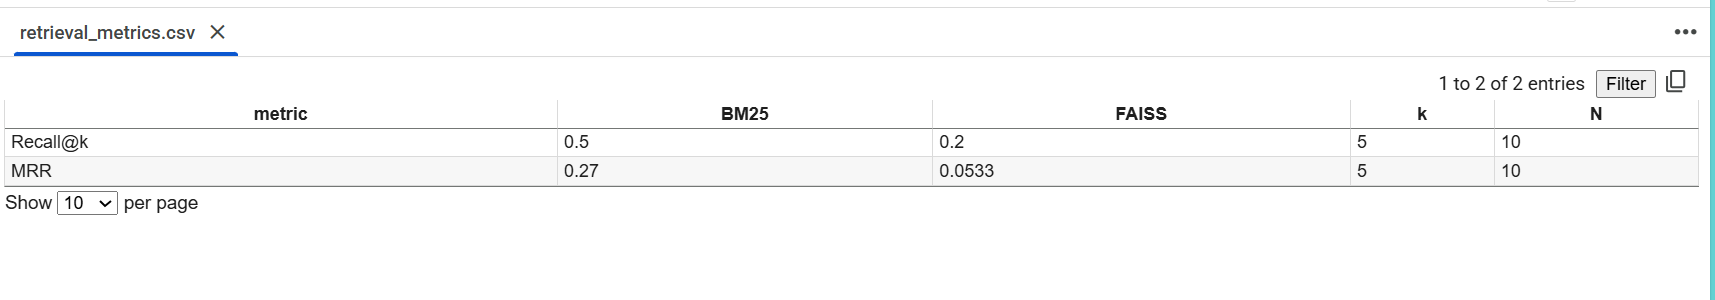

## Быстрый тест гибридного поиска + reranker

In [ ]:
#@title Hybrid quick test
q = "Как вызвать мастера?"
out = answer_with_rag(q, retriever="hybrid", k=globals().get("TOP_K",5), use_reranker=True)
pretty_print_result(out)


## Утилита для «живых» вопросов из одной ячейки

In [ ]:
#@title Ask me anything (RAG)
question = "Как быстро выезжает мастер для демонтажа?"
mode = "bm25"   # bm25 | faiss | hybrid
use_rerank = False

out = answer_with_rag(question, retriever=mode, k=globals().get("TOP_K",5), use_reranker=use_rerank)
pretty_print_result(out)


In [ ]:
#@title Мини-дашборд: BM25 vs FAISS (Recall@k / MRR)
import math
import pandas as pd
import matplotlib.pyplot as plt

# Требования:
# - Должны быть определены: GOLD, eval_retrieval, retriever_bm25_k, retriever_faiss_k
assert "GOLD" in globals(), "Определите словарь GOLD с тестовыми вопросами и критериями релевантности."
assert isinstance(GOLD, dict), "GOLD должен быть dict."
assert len(GOLD) > 0, "GOLD пуст. Добавьте 10+ вопросов для осмысленных метрик."
assert "eval_retrieval" in globals(), "Не найдена функция eval_retrieval."
assert "retriever_bm25_k" in globals() and "retriever_faiss_k" in globals(), "Нет retriever_* функций."

# Набор k для проверки
k_values = [1, 3, 5, 10]

rows = []
for k in k_values:
    bm = eval_retrieval(GOLD, retriever_bm25_k, k=k)
    fa = eval_retrieval(GOLD, retriever_faiss_k, k=k)
    rows.append({"k": k, "metric": "Recall@k", "BM25": bm["Recall@k"], "FAISS": fa["Recall@k"], "N": bm["N"]})
    rows.append({"k": k, "metric": "MRR",       "BM25": bm["MRR"],       "FAISS": fa["MRR"],       "N": bm["N"]})

df = pd.DataFrame(rows)
display(df)

# ===== График 1: Recall@k vs k =====
fig1 = plt.figure()
sub = df[df["metric"] == "Recall@k"].sort_values("k")
plt.plot(sub["k"], sub["BM25"], marker="o", label="BM25")
plt.plot(sub["k"], sub["FAISS"], marker="o", label="FAISS")
plt.title("Recall@k vs k (BM25 vs FAISS)")
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.legend()
plt.grid(True)
plt.show()

# ===== График 2: MRR vs k =====
fig2 = plt.figure()
sub = df[df["metric"] == "MRR"].sort_values("k")
plt.plot(sub["k"], sub["BM25"], marker="o", label="BM25")
plt.plot(sub["k"], sub["FAISS"], marker="o", label="FAISS")
plt.title("MRR vs k (BM25 vs FAISS)")
plt.xlabel("k")
plt.ylabel("MRR")
plt.legend()
plt.grid(True)
plt.show()

# Сохранить таблицу метрик в CSV
df.to_csv("retrieval_metrics_by_k.csv", index=False, encoding="utf-8")
print("Saved: retrieval_metrics_by_k.csv")



## Как читать графики


* **Recall\@k:** доля вопросов, где среди Top-k есть хотя бы один «правильный» фрагмент. Линия ближе к 1.0 — лучше.

* **Recall\@k vs k**: чем выше кривая, тем чаще среди Top-k есть релевантный фрагмент.

  * Если FAISS растёт быстрее при больших k — у вас выигрывает **семантика**.
  * Если BM25 лидирует на малых k — запросы и документы хорошо «рифмуются» по ключевым словам.

* **MRR:** средняя «скорость» нахождения первого релевантного фрагмента (выше — лучше).
  Если линии FAISS обгоняют BM25 при больших `k` — dense выигрывает по семантике; если BM25 лучше на малом `k`, у вас хорошо работают точные совпадения терминов.  
* **MRR vs k**: насколько «рано» находится первый релевантный фрагмент (выше — лучше).

  * Падение MRR при нормальном Recall намекает на **слабое ранжирование** → включайте **reranker**.
* Если обе метрики низкие: проверьте **чанкование/overlap, чистоту данных, метаданные, расширение запроса (HyDE/multi-query)**.


# Частые ошибки и как их избежать

* **Чанки без overlap** → теряются связи между абзацами.
* **Слишком большие чанки** → шум в prompt, рост стоимости.
* **Сырые документы** → мусорные символы, таблицы без нормализации.
* **Смешение доменов** → эмбеддинги “плавают”, падение точности.
* **Нет проверок на пустой контекст** → галлюцинации.
* **Отсутствие источников в ответе** → нет проверяемости.



## Что сделали

* Разобрали идею **RAG = retrieval + generation**: поиск релевантного контекста → контролируемая генерация.
* Собрали **классическую архитектуру**: источник → парсинг → **чанкование (+overlap)** → индекс → **retriever** (BM25 / FAISS / hybrid) → *(опц.)* **reranker** → **prompt с cite-контекстом** → LLM.
* Реализовали:

  * Мини-RAG на **BM25** (sparse).
  * Мини-RAG на **FAISS** с эмбеддингами (dense).
  * **Hybrid** (сведение BM25+FAISS) и **cross-encoder reranker**.
  * Метрики **Recall\@k / MRR**, end-to-end чек (faithfulness proxy, наличие цитирования).
  * Диагностику запроса (idf/кандидаты), **HyDE**, **multi-query**, query expansion.
  * Мини-дашборд (matplotlib) для сравнения **BM25 vs FAISS** по k.

## Ключевые выводы

1. **RAG снижает галлюцинации и повышает проверяемость** за счёт опоры на внешний контекст и явных ссылок на источники.
2. **BM25**:

   * Силен на **малых корпусах** и при **точных формулировках** (ключевые слова).
   * Простой и быстрый, даёт конкурентный **Recall\@k** при k=1–5.
3. **FAISS + эмбеддинги**:

   * Выигрывает при **синонимах/перефразах**, доменной лексике, **мультиязычности**, **больших корпусах**.
   * Часто растёт лучше по Recall при увеличении k (k=5–10), особенно с **reranker**.
4. **Hybrid + reranker** — лучший baseline качества:

   * Объединение кандидатов BM25 и FAISS + **cross-encoder** обычно даёт максимальную точность Top-k при умеренной цене вычислений.
5. **Чанкование критично**:

   * Практичный диапазон: **600–1000** символов, **overlap 100–200**.
   * Слишком маленькие чанки → распад контекста; слишком большие → шум и рост токенов в prompt.
6. **Оценка качества**:

   * Отдельно измеряйте retrieval (**Recall\@k, MRR**) и end-to-end (faithfulness, наличие **цитирования**).
   * Делайте свой **GOLD-набор из 15–30 вопросов** с простыми правилами матчинга (по source/text\_contains).
7. **Стоимость и производительность**:

   * Ограничивайте Top-k и размер контекста; применяйте **rerank** к \~20–50 кандидатам.
   * Кэшируйте эмбеддинги/результаты поиска; используйте batch-кодирование.
   * Для средних корпусов хватает **faiss-cpu**; для очень больших — GPU/шардирование.
8. **Данные и метаданные**:

   * Нормализуйте текст (чистка, переносы, таблицы), убирайте дубликаты.
   * Храните **метаданные** (раздел, дата, автор) — пригодится для фильтров и сужения поиска.
9. **Промпт и guardrails**:

   * Явно требуйте: «отвечать **строго по контексту**» + выводить **источники** вида `[path#chunk]`.
   * Правило: **нет ответа в контексте → сказать об этом и предложить уточнение**.







# Расширения (куда двигаться дальше)

* **Hybrid-поиск** (BM25 + dense, ранжирование суммой/взвешиванием).
* **Reranking** (cross-encoder) для повышения точности Top-k.
* **HyDE / multi-query / query expansion** для усиления запроса.
* **Метаданные и фильтры** (по разделу, дате, автору).
* **Онлайн-обновление индекса**, инкрементальные пайплайны, кэш.
* **Guardrails**: запреты на ответ без источника, формат JSON и т.п.
